In [287]:
import tensorflow as tf
import cv2
import numpy as np
import math
from matplotlib import pyplot as plt
import seaborn as sns
import time
import os

In [288]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available:  0


In [289]:
patch_size = 32
kernel_size = patch_size
image_size = 256
descriptor_dimension = 4

max_rotation = 360
rotation_multiple = 5
max_skew = 0

margin = 1.5
threshold = 0.4
learning_rate = 0.1e-2
optimizer = tf.keras.optimizers.Adam(learning_rate = learning_rate)
cos_sim = tf.keras.losses.CosineSimilarity()
batch_size = 1
epochs = 100000
num_filters = 4
num_sin_waves = 4
model_path = "filters_model.h5"
backup_model_path = "backup_filters_model.h5"

In [290]:
centre_to_top_right = np.array([[1,0,-math.ceil(image_size/2)],
                                [0,1,-math.ceil(image_size/2)],
                                [0,0,1]])
top_right_to_centre = np.array([[1,0,math.ceil(image_size/2)],
                                [0,1,math.ceil(image_size/2)],
                                [0,0,1]])

patch_centre_to_top_right = np.array([[1,0,-math.ceil(patch_size/2)],
                                [0,1,-math.ceil(patch_size/2)],
                                [0,0,1]])
patch_top_right_to_centre = np.array([[1,0,math.ceil(patch_size//2)],
                                [0,1,math.ceil(patch_size//2)],
                                [0,0,1]])

def create_rotational_matrix(rotation, axis = "z"):
    rotation = np.radians(rotation)
    s = np.sin(rotation)
    c = np.cos(rotation)
    if axis == "z":
        return np.array([[c, -s, 0],
                          [s, c, 0],
                          [0, 0, 1]])
        
def create_skew_matrix(skew_x, skew_y):
     return np.array([[1, skew_x, 0],
                     [skew_y, 1, 0],
                     [0, 0, 1]])

In [291]:
def get_fixed_homography_matrix(val):
    rotation = rotation_multiple*val
    # rotation = (rotation//rotation_multiple) * rotation_multiple
    skew_x = np.random.uniform(0,max_skew)
    skew_y = np.random.uniform(0,max_skew)

    rotation_matrix = create_rotational_matrix(rotation)
    skew_matrix = create_skew_matrix(skew_x, skew_y)
    homography_matrix = np.matmul(patch_top_right_to_centre, np.matmul(np.matmul(skew_matrix, rotation_matrix), patch_centre_to_top_right))
    return homography_matrix

In [292]:
def get_random_homography_matrix(whole_image =False):
    rotation = np.random.uniform(0,max_rotation)
    rotation = (rotation//rotation_multiple) * rotation_multiple
    skew_x = np.random.uniform(0,max_skew)
    skew_y = np.random.uniform(0,max_skew)

    rotation_matrix = create_rotational_matrix(rotation)
    skew_matrix = create_skew_matrix(skew_x, skew_y)
    homography_matrix = np.matmul(top_right_to_centre if whole_image else patch_top_right_to_centre, np.matmul(np.matmul(skew_matrix, rotation_matrix), centre_to_top_right if whole_image else  patch_centre_to_top_right))
    return homography_matrix

In [293]:
class CustomDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, image_dir_path, batch_size = 128):
        
        self.img_list = []
        for image in os.listdir(image_dir_path):
            if image == ".DS_Store":
                continue
            
            # img = cv2.imread(os.path.join(image_dir_path, image))
            # img = cv2.resize(img, (image_size, image_size))
            # img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
            # img = img/255
            self.img_list.append(os.path.join(image_dir_path, image))
            
        self.batchsize = batch_size  
                
    def __len__(self):
        return math.ceil(((image_size - patch_size)**2)/self.batchsize)
        
    def __getitem__(self, batch):
        original_images = []
        matches = []
        non_matches = []
        while len(original_images) < self.batchsize:
            kp = None
            while(kp is None):
                current_image_no = np.random.randint(0, len(self.img_list))
                current_image_path = self.img_list[current_image_no]
                current_image = cv2.imread(current_image_path)
                current_image = cv2.resize(current_image, (image_size, image_size))
                current_image = cv2.cvtColor(current_image, cv2.COLOR_RGB2GRAY)
                current_image = current_image/255
                orb= cv2.ORB_create(100)
                kp = orb.detect((np.repeat(np.expand_dims(current_image,-1),3,-1)*255).astype(np.uint8))
                if len(kp) < 5:
                    kp = None
            k=0
            got =False
            while(not got):
                k=np.random.choice(kp)
                if(k.pt[0] >(patch_size/2) and k.pt[1] >(patch_size/2) and k.pt[1]<image_size-((patch_size/2) )and k.pt[0]<image_size-((patch_size/2))):
                    got = True
            x= k.pt[0]
            y= k.pt[1]
            
            
            current_patch = current_image[int(y-patch_size/2):int(y+patch_size/2), int(x-patch_size/2):int(x+patch_size/2)]
            # current_patch = cv2.blur(current_patch, (3,3))
            #transform image 
            H=get_random_homography_matrix(True)
            transformed_image = cv2.warpPerspective(current_image, H, (image_size , image_size))
            points_to_transform = np.array([[x, y]], dtype='float32')
            points_to_transform = np.expand_dims(points_to_transform, axis=0)  # Add an extra dimension for the transformation
            transformed_points = cv2.perspectiveTransform(points_to_transform, H)

            # transformed_current_patch = cv2.warpPerspective(current_patch, get_random_homography_matrix(), (patch_size, patch_size))
            # transformed_current_patch = cv2.blur(transformed_current_patch, (3,3))
            x= transformed_points[0][0][0]
            y= transformed_points[0][0][1]
        
            transformed_current_patch = transformed_image[int(y-patch_size/2):int(y+patch_size/2), int(x-patch_size/2):int(x+patch_size/2)]
            current_patch = np.expand_dims(current_patch, axis = -1)
            transformed_current_patch = np.expand_dims(transformed_current_patch, axis = -1)
            # test_original_image =(np.repeat(np.expand_dims(current_image,-1),3,-1)*255).astype(np.uint8)
            # test_transformed_image = (np.repeat(np.expand_dims(transformed_image,-1),3,-1)*255).astype(np.uint8)
            # cv2.circle(test_original_image,(int( k.pt[0]), int(k.pt[1])),3,(255,0,0))
            # cv2.circle(test_transformed_image,(int(transformed_points[0][0][0]), int(transformed_points[0][0][1])),3,(255,0,0))
            
            original_images.append(current_patch)
            matches.append(transformed_current_patch)
            
            # X = np.random.randint(0,image_size - patch_size)
            # Y = np.random.randint(0,image_size - patch_size)
            # random_image_no = np.random.randint(0, len(self.img_list))
            # random_image = self.img_list[random_image_no]
            # while(x==X & y==Y & random_image_no == current_image_no):
            #     X = np.random.randint(0,image_size - patch_size)
            #     Y = np.random.randint(0,image_size - patch_size)
            k_r=k
            got=False
            while(k.pt == k_r.pt or (not got)):
                k_r=np.random.choice(kp)
                if(k_r.pt[0] >(patch_size/2) and k_r.pt[1] >(patch_size/2) and k_r.pt[1]<image_size-((patch_size/2))and k_r.pt[0]<image_size-((patch_size/2))):
                    got=True
            
            H=get_random_homography_matrix(True)
            transformed_image = cv2.warpPerspective(current_image, H, (image_size, image_size))
            points_to_transform = np.array([[k_r.pt[0], k_r.pt[1]]], dtype='float32')
            points_to_transform = np.expand_dims(points_to_transform, axis=0)  # Add an extra dimension for the transformation
            transformed_points = cv2.perspectiveTransform(points_to_transform, H)

            # transformed_current_patch = cv2.warpPerspective(current_patch, get_random_homography_matrix(), (patch_size, patch_size))
            # transformed_current_patch = cv2.blur(transformed_current_patch, (3,3))
            x= transformed_points[0][0][0]
            y= transformed_points[0][0][1]
            transformed_current_patch = transformed_image[int(y-patch_size/2):int(y+patch_size/2), int(x-patch_size/2):int(x+patch_size/2)]
            transformed_current_patch = np.expand_dims(transformed_current_patch, axis = -1)
            non_matches.append(transformed_current_patch)

            if not ((non_matches[-1].shape == matches[-1].shape) & (original_images[-1].shape == matches[-1].shape)):
                original_images.pop()
                matches.pop()
                non_matches.pop()
        
        original_images = np.array(original_images)
        matches = np.array(matches)
        non_matches = np.array(non_matches)
            
            # original_images = np.array(original_images > threshold, dtype=np.double)
            # matches = np.array(matches > threshold, dtype=np.double)
            # non_matches = np.array(non_matches > threshold, dtype=np.double)
            
        return original_images, matches, non_matches

In [294]:
# test_data_gen = CustomDataGenerator("real_images", batch_size)
# print("Test data generation")
# o,t,r = test_data_gen.__getitem__(0)
# fig, axes = plt.subplots(1, 3, figsize=(10, 5))
# axes[0].imshow(o[0]*1,cmap='gray')
# # axes[0].imshow(o[0]*255)
# axes[0].set_title('First Image')
# axes[0].axis('off')

# # Plot the second image
# axes[1].imshow(t[0]*1,cmap='gray')
# # axes[1].imshow(t[0]*255)
# axes[1].set_title('Second Image')
# axes[1].axis('off')

# axes[2].imshow(r[0]*1,cmap='gray')
# # axes[1].imshow(t[0]*255)
# axes[2].set_title('random  Image')
# axes[2].axis('off')

# # Display the plot
# plt.tight_layout()
# plt.show()

In [295]:
tan_inverse = np.zeros((patch_size, patch_size))
distances = np.zeros((patch_size, patch_size))
center_i, center_j = tan_inverse.shape[0]//2, tan_inverse.shape[1]//2
for i in range(tan_inverse.shape[0]):
    for j in range(tan_inverse.shape[1]):
        tan_inverse[i,j] = np.arctan2(i - center_i, j - center_j)
        distances[i,j] = np.sqrt((i - center_i)**2 + (j - center_j)**2)

In [296]:
Amplitudes = []
Freq = []
Phase = []
Radius = []
for i in range(num_filters):
    amp = []
    freq = []
    phase = []
    for j in range(num_sin_waves):
        amp.append( tf.Variable(np.random.uniform(0,1)))
        freq.append(tf.Variable(np.asarray(np.random.randint(8,10),np.float32)))
        phase.append(tf.Variable(np.random.normal()))
        
    Amplitudes.append(amp)
    Freq.append(freq)
    Phase.append(phase)
    Radius.append((patch_size/2) * np.random.uniform(0, 1))

In [297]:
def create_circle_sine_wave_image(Amp, Freq, Phase, Radius, tan_inverse, distances):
    values = np.zeros((len(Amplitudes), len(Amplitudes[0]), len(tan_inverse), len(tan_inverse[0])))
    print("=======")
    print(values)
    for i in range(len(Amp)):
        for j in range(len(Amp[0])):
            values[i, j] = Freq[i][j] * tan_inverse
            
    print("=======")
    print(values)
    for i in range(len(Amp)):
        for j in range(len(Amp[0])):
            values[i, j] = Phase[i][j] + values[i][j]
    print("=======")
    print(values)
    values[i, j] = tf.sin(values[i, j])
    print("=======")
    print(values)
    for i in range(len(Amp)):
        for j in range(len(Amp[0])):
            values[i, j] = Amp[i][j] * values[i][j]
    print("=======")
    print(values)
    for i in range(len(Radius)):
        values[i] = Radius[i] * values[i]
    print("=======")
    print(values)
    values = tf.reduce_sum(values, axis=1)
    print("=======")
    print(values)
    
    return values
    

In [298]:
def one_filter(amplitude,freq,phase,radius,tan_inverse,distances):
    res=tf.zeros(tan_inverse.shape,dtype=tf.float32)
    for i in range(len(amplitude)):
        res=res+amplitude[i]* tf.sin(freq[i] *tan_inverse + phase[i])
    f=  2-tf.abs(distances - radius*(1+res))
    one=tf.ones(f.shape,dtype=tf.float32)
    zeros=tf.zeros(f.shape,dtype=tf.float32)
    f=tf.where(f>0,one,zeros)
    return f

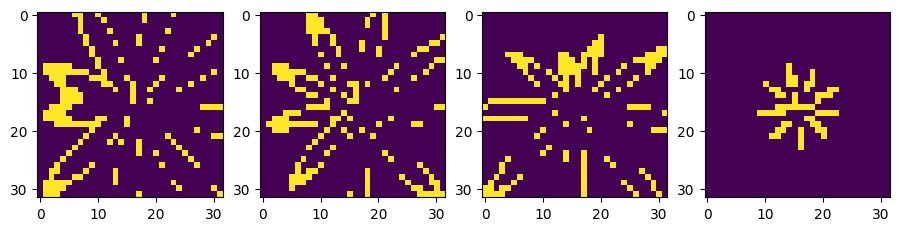

In [299]:
filters = []
fig, ax = plt.subplots(ncols=num_filters, figsize = (11,6))
for i in range(num_filters):
    filters.append(one_filter(Amplitudes[i], Freq[i], Phase[i], Radius[i], tan_inverse, distances))
    ax[i].imshow(filters[i])

[[[[0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   ...
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]]

  [[0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   ...
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]]

  [[0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   ...
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]]

  [[0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   ...
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]]]


 [[[0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   ...
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]]

  [[0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   ...
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
 

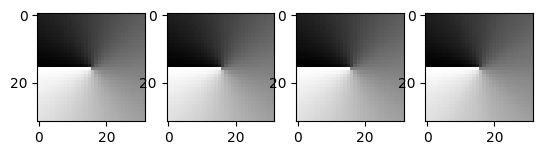

In [300]:
v = create_circle_sine_wave_image(Amplitudes, Freq, Phase, Radius, tan_inverse, distances)
fig, ax = plt.subplots(ncols=len(v))
for i in range(len(v)):
    ax[i].imshow(v[i], cmap = "gray")

In [301]:
def create_circle_sine_wave_image(width, height, R, A, B, Sigma, Delta, alpha, beta):
    image = np.zeros((height, width), dtype=np.uint8)
    center_x = width // 2
    center_y = height // 2
    a= A*R
    b=B* R
    for y in range(height):
        for x in range(width):
            theta = np.arctan2(y - center_y, x - center_x)
            distance = np.sqrt((x - center_x)**2 + (y - center_y)**2)
            
            
            angle_repeat_range = 10
            threshold = 2
            
            # Amplitudes
           
            
            # Frequencies
            sigma = Sigma * angle_repeat_range
            delta = Delta * angle_repeat_range
            # print(a)
            
            # Phases
            f =  (a * np.sin(float(sigma) * float(theta) + float(alpha)) + b * np.sin(float(delta) * float(theta) + (beta)) )
            
            if abs(f + R - distance) < threshold:
                image[y, x] = 255
    
    return image

In [302]:
pattern_images = []
for _ in range(num_filters):
    pattern_images.append(create_circle_sine_wave_image(width=patch_size,
                                                        height=patch_size,
                                                        R=patch_size//2,
                                                        A=np.random.uniform(0,1),
                                                        B=np.random.uniform(0,1),
                                                        Sigma=np.random.randint(0,50),
                                                        Delta=np.random.randint(0,50),
                                                        alpha=np.random.normal(),
                                                        beta=np.random.normal()))

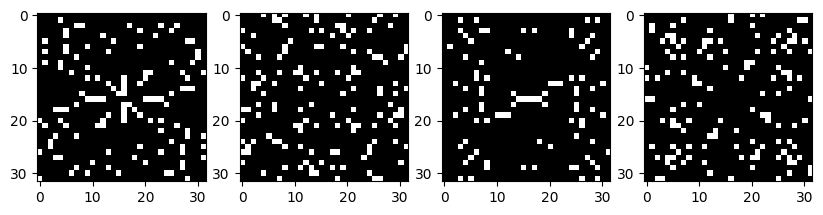

In [303]:
fig, ax = plt.subplots(ncols=num_filters, figsize=(10,20))
for i,pattern_image in enumerate(pattern_images):
    ax[i].imshow(pattern_image, cmap='gray')

In [304]:
def check_active_points(image, filters):
    vector = np.zeros((len(filters)))
    for c, filter in enumerate(filters):
        count = 0
        h, w = image.shape[:2]
        center_j = w//2
        center_i = h//2
        for i in range(h):
            for j in range(w):
                if not filter[i, j] == 0:
                    if image[center_i, center_j] < image[i,j]:
                        count += 1
        vector[c] = count
    return vector

In [305]:
o_vector = check_active_points(o[0], pattern_images)
t_vector = check_active_points(t[0], pattern_images)
r_vector = check_active_points(r[0], pattern_images)

NameError: name 'o' is not defined

In [ ]:
print(np.sqrt(np.sum((o_vector - t_vector)**2)))
print(np.sqrt(np.sum((o_vector - r_vector)**2)))


0.0
241.62574366155607
